# ТЗ на ШИФТ Курсы: Кто прошел через турникеты?

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

Загрузка обучающих данных

In [2]:
train = pd.read_csv('train.csv', index_col=0) 

In [3]:
train 

,user_id,ts,gate_id
0,18,2022-07-29 09:08:54,7
1,18,2022-07-29 09:09:54,9
3,18,2022-07-29 09:10:06,5
4,18,2022-07-29 09:10:08,5
5,18,2022-07-29 09:10:34,10
...,...,...,...
37512,6,2022-12-31 17:21:19,10
37513,6,2022-12-31 20:38:56,11
37514,6,2022-12-31 20:39:22,6
37515,6,2022-12-31 20:39:23,6


Загрузка тестовых данных

In [4]:
test = pd.read_csv('test.csv', index_col=0)

In [5]:
test

,ts,gate_id,lost_id
37518,2023-01-03 08:21:00,9,1
37520,2023-01-03 08:21:18,5,1
37521,2023-01-03 08:21:19,5,1
37522,2023-01-03 08:21:39,10,1
37523,2023-01-03 08:32:49,15,19
...,...,...,...
44637,2023-02-24 17:08:57,10,15
44638,2023-02-24 19:43:36,11,15
44639,2023-02-24 19:44:00,4,15
44640,2023-02-24 19:44:01,4,15


## Разведочный анализ данных 

Перед тем как формулировать гипотезы и генерировать признаки, проведем разведочный анализ данных, чтобы лучше понять структуру и содержание данных.

Информация об обучающих данных

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35172 entries, 0 to 37516
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  35172 non-null  int64 
 1   ts       35172 non-null  object
 2   gate_id  35172 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


Информация об тестовых данных

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6620 entries, 37518 to 44641
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ts       6620 non-null   object
 1   gate_id  6620 non-null   int64 
 2   lost_id  6620 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 206.9+ KB


число дубликатов в датасете train и test

In [8]:
print(train.duplicated().sum())
print(test.duplicated().sum())

0
0


Преобразование времени в формат datetime для удобства работы с временными данными

In [9]:
train['ts'] = pd.to_datetime(train['ts'])  # Преобразование столбца 'ts' в формат datetime в обучающих данных
test['ts'] = pd.to_datetime(test['ts'])  # Преобразование столбца 'ts' в формат datetime в тестовых данных
train['date'] = train['ts'].dt.date  # Извлечение даты из временной метки и сохранение в новый столбец 'date' в обучающих данных
test['date'] = test['ts'].dt.date  # Извлечение даты из временной метки и сохранение в новый столбец 'date' в тестовых данных

In [10]:
train

,user_id,ts,gate_id,date
0,18,2022-07-29 09:08:54,7,2022-07-29
1,18,2022-07-29 09:09:54,9,2022-07-29
3,18,2022-07-29 09:10:06,5,2022-07-29
4,18,2022-07-29 09:10:08,5,2022-07-29
5,18,2022-07-29 09:10:34,10,2022-07-29
...,...,...,...,...
37512,6,2022-12-31 17:21:19,10,2022-12-31
37513,6,2022-12-31 20:38:56,11,2022-12-31
37514,6,2022-12-31 20:39:22,6,2022-12-31
37515,6,2022-12-31 20:39:23,6,2022-12-31


In [11]:
test

,ts,gate_id,lost_id,date
37518,2023-01-03 08:21:00,9,1,2023-01-03
37520,2023-01-03 08:21:18,5,1,2023-01-03
37521,2023-01-03 08:21:19,5,1,2023-01-03
37522,2023-01-03 08:21:39,10,1,2023-01-03
37523,2023-01-03 08:32:49,15,19,2023-01-03
...,...,...,...,...
44637,2023-02-24 17:08:57,10,15,2023-02-24
44638,2023-02-24 19:43:36,11,15,2023-02-24
44639,2023-02-24 19:44:00,4,15,2023-02-24
44640,2023-02-24 19:44:01,4,15,2023-02-24


Построим графики распределения для временных меток и идентификаторов турникетов.

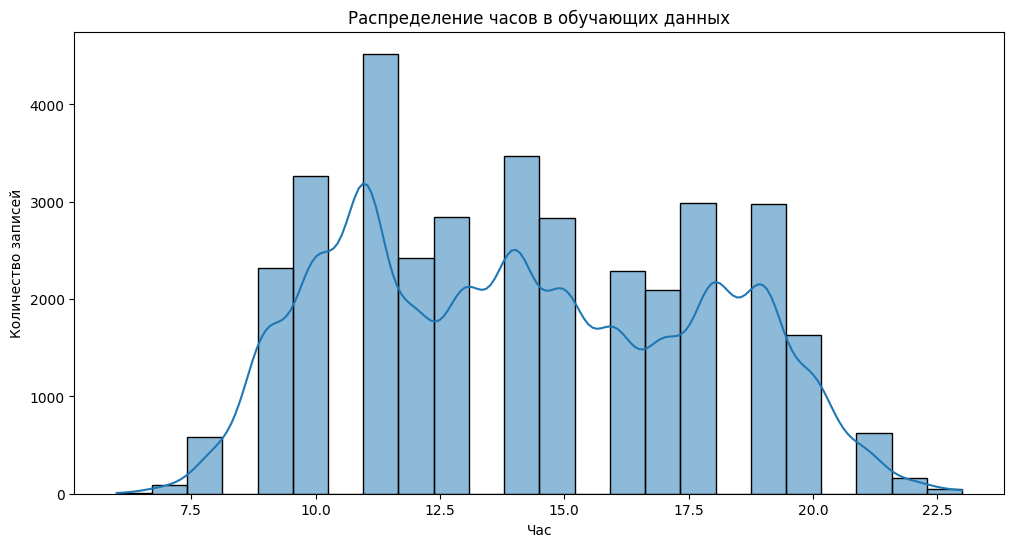

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(train['ts'].dt.hour, bins=24, kde=True)
plt.title('Распределение часов в обучающих данных')
plt.xlabel('Час')
plt.ylabel('Количество записей')
plt.show()

Подсчитаем количество записей для каждого пользователя и визуализируем это распределение.

C:\Users\User\AppData\Local\Temp\ipykernel_16152\3352137726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_activity.index, y=user_activity.values, palette='viridis')


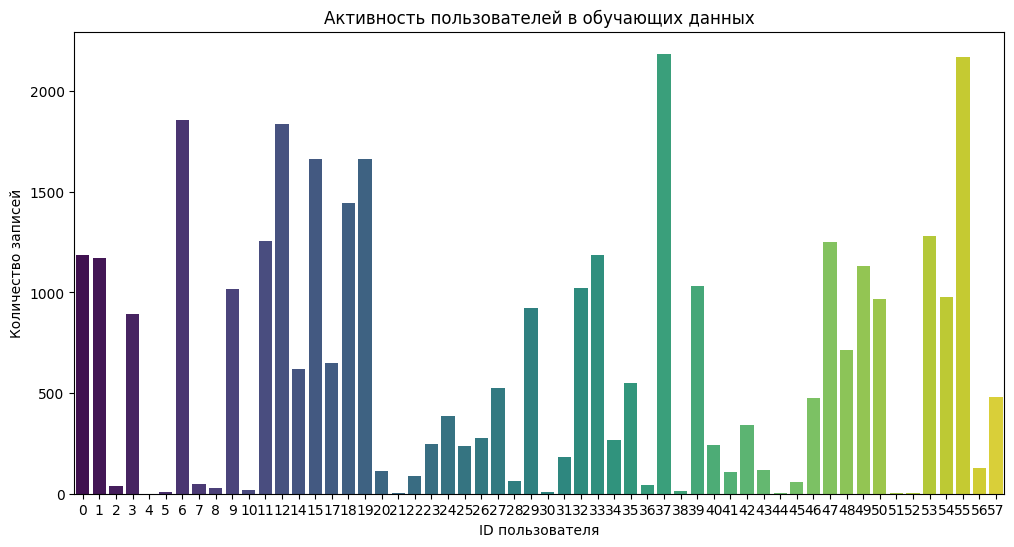

In [13]:
user_activity = train['user_id'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=user_activity.index, y=user_activity.values, palette='viridis')
plt.title('Активность пользователей в обучающих данных')
plt.xlabel('ID пользователя')
plt.ylabel('Количество записей')
plt.show()

Построим график, показывающий количество записей для каждого турникета.

C:\Users\User\AppData\Local\Temp\ipykernel_16152\4237800992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gate_usage.index, y=gate_usage.values, palette='plasma')


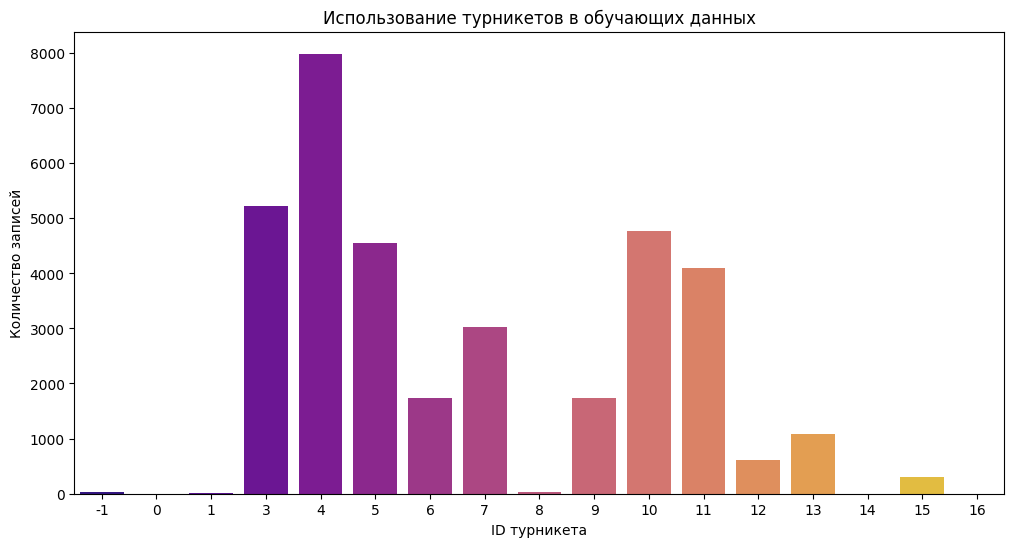

In [14]:
gate_usage = train['gate_id'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=gate_usage.index, y=gate_usage.values, palette='plasma')
plt.title('Использование турникетов в обучающих данных')
plt.xlabel('ID турникета')
plt.ylabel('Количество записей')
plt.show()

## Гипотезы и генерация признаков
На основе проведенного анализа данных можно сформулировать следующие гипотезы:

Гипотеза 1: Активность пользователей зависит от времени суток. Например, пиковая нагрузка может наблюдаться в утренние и вечерние часы.

Признаки: Час, минута, секунда, количество минут от начала дня.
Гипотеза 2: Пользователи с большим количеством записей могут иметь более предсказуемое поведение.

Признаки: Количество записей для каждого пользователя за день.
Гипотеза 3: Некоторые турникеты используются чаще других, что может указывать на их важность или популярность.

Признаки: Количество проходов через каждый турникет, вероятность прохода через турникет.
Гипотеза 4: Последовательность проходов через турникеты может содержать полезную информацию о поведении пользователей.

Признаки: Сдвиги значений турникетов и времени для каждого пользователя.

## Анализ данных 

Подсчитаем и отсортируем сколько раз встреча6тся запись о каждом пользователе в обучающей выборке

In [15]:
train.user_id.value_counts()

user_id
37    2184
55    2166
6     1857
12    1837
19    1661
15    1659
18    1441
53    1279
11    1255
47    1250
33    1184
0     1184
1     1171
49    1129
39    1032
32    1020
9     1015
54     977
50     965
29     924
3      894
48     712
17     648
14     617
35     549
27     523
57     482
46     475
24     386
42     340
26     279
34     267
23     247
40     242
25     238
31     181
56     129
43     117
20     112
41     110
22      87
28      64
45      57
7       48
36      45
2       39
8       27
10      17
38      13
5       10
30      10
52       5
21       5
44       4
51       2
4        1
Name: count, dtype: int64

Сгруппируем данные по идентификатору пользователя (user_id), чтобы вычислить количество записей (counts) и количество уникальных дат (date_unique) для каждого пользователя. Это позволит нам оценить активность пользователей и разнообразие дней, в которые они появляются в данных. Затем отсортируем результаты по количеству записей и выведем первые 7 пользователей с наименьшим количеством записей, чтобы выявить наименее активных пользователей.

In [16]:
grp_user = train.groupby('user_id').agg(
    counts=('ts', 'count'),
    date_unique=('date', lambda x: x.nunique()))
grp_user.sort_values(['counts']).head(7)

,counts,date_unique
user_id,,
4,1,1
51,2,2
44,4,1
52,5,1
21,5,2
5,10,2
30,10,2


Удалим пользователей с малым количеством данных

In [17]:
user_id_to_delete = [4, 51, 44, 21, 52]  # Список пользователей, которых нужно удалить из данных
train = train[~train['user_id'].isin(user_id_to_delete)]  # Удаление пользователей из списка user_id_to_delete из обучающих данных

Подсчитаем количество записей о каждом турнекете в данных для обученния и отсортируем результаты по индексу

In [18]:
train_gate = train['gate_id'].value_counts(dropna = False).sort_index()
train_gate

gate_id
-1       25
 0        2
 1        5
 3     5219
 4     7976
 5     4548
 6     1739
 7     3025
 8       23
 9     1728
 10    4767
 11    4090
 12     619
 13    1087
 14       1
 15     298
 16       3
Name: count, dtype: int64

Мало данных о турнекетах под номером 0, 1, 14, 16

Подсчитаем количество записей о каждом турнекете в данных для теста и отсортируем результаты по индексу

In [19]:
test_gate = test['gate_id'].value_counts(dropna = False).sort_index()
test_gate

gate_id
-1        1
 1        2
 2        4
 3      893
 4     1431
 5      853
 6      282
 7      540
 8       10
 9      394
 10     915
 11     762
 12     120
 13     310
 14       1
 15     102
Name: count, dtype: int64

Мало данных о турнекетах под номером -1, 2, 4, 14

Определим уникальные идентификаторы турникетов, которые присутствуют только в одном из двух наборов данных: обучающем  или тестовом

In [20]:
# Находим разность между множествами, чтобы определить, какие gate_id присутствуют только в обучающем наборе
only_train = set(train['gate_id']) - set(test['gate_id'])
# Находим разность между множествами, чтобы определить, какие gate_id присутствуют только в тестовом наборе
only_test = set(test['gate_id']) - set(train['gate_id'])

print("Каких gate_id из train нет в test:", only_train)
print("Каких gate_id из test нет в train: ", only_test)

Каких gate_id из train нет в test: {0, 16}
Каких gate_id из test нет в train:  {2}


Так как турникетов 0, 16 нет в тестовой выборке, их можно удалить. Турнекеты с номером -1, 1, 2, 14 в обучающей выборке и турнеекуеты с номерами 0, 1, 14, 16 в тестовой выборке встречаются 4 и менее раз, для лучшей работы модели их можно удалить

In [21]:
list_gate_id_del = [-1, 0, 1, 2, 14, 16]  # Список турникетов, которые нужно удалить из данных
train = train[~train['gate_id'].isin(list_gate_id_del)]  # Удаление турникетов из списка list_gate_id_del из обучающих данных
test = test[~test['gate_id'].isin(list_gate_id_del)]  # Удаление турникетов из списка list_gate_id_del из тестовых данных

## Обработка данных

Функция для обработки данных

In [22]:
def process_data(df, is_train=True): 
    df['ts'] = pd.to_datetime(df['ts'])  # Преобразование столбца 'ts' в формат datetime
    df['day'] = df['ts'].dt.day  # Извлечение дня из временной метки
    df['hour'] = df['ts'].dt.hour  # Извлечение часа из временной метки
    df['minute'] = df['ts'].dt.minute  # Извлечение минуты из временной метки
    df['second'] = df['ts'].dt.second  # Извлечение секунды из временной метки
    df['minutes'] = df['hour'] * 60 + df['minute']  # Вычисление количества минут от начала дня
    df['seconds'] = df['minutes'] * 60 + df['second']  # Вычисление количества секунд от начала дня
    df['weekday'] = df['ts'].dt.dayofweek  # Извлечение дня недели из временной метки
    df['Dow2'] = (df['ts'].dt.dayofyear % 4).apply(lambda x: int(x in (1, 2)))  # Вычисление признака Dow2
    df['Dow2_2'] = (df['ts'].dt.dayofyear % 4).apply(lambda x: int(x < 2))  # Вычисление признака Dow2_2

    user_col = 'user_id' if is_train else 'lost_id'  # Определение имени столбца с идентификатором пользователя
    df.sort_values([user_col, 'ts'], inplace=True)  # Сортировка данных по пользователю и времени
    df['date'] = df['ts'].dt.date  # Извлечение даты из временной метки

    first_entry_exit_per_day = df.groupby([user_col, 'date'], as_index=False)['ts'].agg(['min', 'max']).reset_index()  # Вычисление первого и последнего времени для каждого пользователя за день
    first_entry_exit_per_day['time_diff'] = (first_entry_exit_per_day['max'] - first_entry_exit_per_day['min']).dt.total_seconds() / 60  # Вычисление разницы во времени в минутах
    first_entry_exit_per_day['count'] = df.groupby([user_col, 'date']).count()['ts'].reset_index(name='count')['count']  # Вычисление количества записей для каждого пользователя за день
    df = pd.merge(df, first_entry_exit_per_day[[user_col, 'date', 'time_diff', 'count']], on=[user_col, 'date'], how='left')  # Объединение данных с вычисленными признаками

    grouped_data = df.groupby([user_col, 'date'])  # Группировка данных по пользователю и дате
    first_gate = grouped_data['gate_id'].first().reset_index()  # Извлечение первого турникета для каждого пользователя за день
    last_gate = grouped_data['gate_id'].last().reset_index()  # Извлечение последнего турникета для каждого пользователя за день
    df = pd.merge(df, first_gate, on=[user_col, 'date'], how='left', suffixes=('', '_first'))  # Объединение данных с первым турникетом
    df = pd.merge(df, last_gate, on=[user_col, 'date'], how='left', suffixes=('', '_last'))  # Объединение данных с последним турникетом

    gate_counts = df.groupby([user_col, 'gate_id'])[user_col].count().reset_index(name='gate_count')  # Вычисление количества проходов через каждый турникет для каждого пользователя
    gate_counts['gate_prob'] = gate_counts.groupby(user_col)['gate_count'].transform(lambda x: np.exp(x) / np.exp(x).sum())  # Вычисление вероятности прохода через турникет
    df = pd.merge(df, gate_counts[[user_col, 'gate_id', 'gate_prob']], on=[user_col, 'gate_id'], how='left')  # Объединение данных с вероятностью прохода через турникет

    return df  # Возврат обработанных данных

Обработка данных

In [23]:
train

,user_id,ts,gate_id,date
0,18,2022-07-29 09:08:54,7,2022-07-29
1,18,2022-07-29 09:09:54,9,2022-07-29
3,18,2022-07-29 09:10:06,5,2022-07-29
4,18,2022-07-29 09:10:08,5,2022-07-29
5,18,2022-07-29 09:10:34,10,2022-07-29
...,...,...,...,...
37512,6,2022-12-31 17:21:19,10,2022-12-31
37513,6,2022-12-31 20:38:56,11,2022-12-31
37514,6,2022-12-31 20:39:22,6,2022-12-31
37515,6,2022-12-31 20:39:23,6,2022-12-31


In [24]:
test

,ts,gate_id,lost_id,date
37518,2023-01-03 08:21:00,9,1,2023-01-03
37520,2023-01-03 08:21:18,5,1,2023-01-03
37521,2023-01-03 08:21:19,5,1,2023-01-03
37522,2023-01-03 08:21:39,10,1,2023-01-03
37523,2023-01-03 08:32:49,15,19,2023-01-03
...,...,...,...,...
44637,2023-02-24 17:08:57,10,15,2023-02-24
44638,2023-02-24 19:43:36,11,15,2023-02-24
44639,2023-02-24 19:44:00,4,15,2023-02-24
44640,2023-02-24 19:44:01,4,15,2023-02-24


In [25]:
train = process_data(train, is_train=True)  # Обработка обучающих данных
test = process_data(test, is_train=False)  # Обработка тестовых данных

C:\Users\User\AppData\Local\Temp\ipykernel_16152\3170316139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ts'] = pd.to_datetime(df['ts'])  # Преобразование столбца 'ts' в формат datetime
C:\Users\User\AppData\Local\Temp\ipykernel_16152\3170316139.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['ts'].dt.day  # Извлечение дня из временной метки
C:\Users\User\AppData\Local\Temp\ipykernel_16152\3170316139.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [26]:
train

,user_id,ts,gate_id,date,day,hour,minute,second,minutes,seconds,weekday,Dow2,Dow2_2,time_diff,count,gate_id_first,gate_id_last,gate_prob
0,0,2022-07-29 10:30:17,3,2022-07-29,29,10,30,17,630,37817,4,1,0,496.033333,12,3,4,3.353501e-04
1,0,2022-07-29 10:30:18,3,2022-07-29,29,10,30,18,630,37818,4,1,0,496.033333,12,3,4,3.353501e-04
2,0,2022-07-29 13:19:21,11,2022-07-29,29,13,19,21,799,47961,4,1,0,496.033333,12,3,4,1.010882e-43
3,0,2022-07-29 13:19:48,6,2022-07-29,29,13,19,48,799,47988,4,1,0,496.033333,12,3,4,2.571347e-56
4,0,2022-07-29 13:19:49,6,2022-07-29,29,13,19,49,799,47989,4,1,0,496.033333,12,3,4,2.571347e-56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35114,57,2022-10-28 15:07:30,4,2022-10-28,28,15,7,30,907,54450,4,1,1,208.000000,6,3,4,9.999939e-01
35115,57,2022-11-18 09:08:56,3,2022-11-18,18,9,8,56,548,32936,4,1,0,743.350000,4,3,4,6.144175e-06
35116,57,2022-11-18 09:08:58,3,2022-11-18,18,9,8,58,548,32938,4,1,0,743.350000,4,3,4,6.144175e-06
35117,57,2022-11-18 21:32:16,4,2022-11-18,18,21,32,16,1292,77536,4,1,0,743.350000,4,3,4,9.999939e-01


In [27]:
test

,ts,gate_id,lost_id,date,day,hour,minute,second,minutes,seconds,weekday,Dow2,Dow2_2,time_diff,count,gate_id_first,gate_id_last,gate_prob
0,2023-01-03 13:42:04,3,0,2023-01-03,3,13,42,4,822,49324,1,0,0,371.666667,5,3,4,2.689414e-01
1,2023-01-03 13:42:06,3,0,2023-01-03,3,13,42,6,822,49326,1,0,0,371.666667,5,3,4,2.689414e-01
2,2023-01-03 19:53:16,11,0,2023-01-03,3,19,53,16,1193,71596,1,0,0,371.666667,5,3,4,5.054832e-13
3,2023-01-03 19:53:42,4,0,2023-01-03,3,19,53,42,1193,71622,1,0,0,371.666667,5,3,4,7.310586e-01
4,2023-01-03 19:53:44,4,0,2023-01-03,3,19,53,44,1193,71624,1,0,0,371.666667,5,3,4,7.310586e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6607,2023-02-18 16:40:26,10,57,2023-02-18,18,16,40,26,1000,60026,5,1,1,13.033333,9,7,9,2.404857e-03
6608,2023-02-18 16:51:07,11,57,2023-02-18,18,16,51,7,1011,60667,5,1,1,13.033333,9,7,9,2.404857e-03
6609,2023-02-18 16:51:32,4,57,2023-02-18,18,16,51,32,1011,60692,5,1,1,13.033333,9,7,9,9.701886e-01
6610,2023-02-18 16:51:34,4,57,2023-02-18,18,16,51,34,1011,60694,5,1,1,13.033333,9,7,9,9.701886e-01


## Добавление сдвигов

Чтобы учесть последовательность событий и временные зависимости в данных, добавим новые признаки в DataFrame, которые представляют собой сдвиги значений турникетов и времени для каждого пользователя. 

Функция для добавления сдвигов по турникетам и времени

In [28]:
def add_shifts(df, user_col, date_col):
    df.sort_values([user_col, 'ts'], inplace=True)  # Сортировка данных по пользователю и времени
    grouped_data = df.groupby([user_col, date_col])  # Данные группируются по пользователю и дате, чтобы сдвиги рассчитывались внутри каждой группы
    for i in range(1, 6):  # Цикл по сдвигам от 1 до 5
        df[f'g{i}'] = grouped_data['gate_id'].shift(-i)  # Создаются новые столбцы, содержащие значения турникетов, сдвинутые вперед и назад на i позиций. Это позволяет учитывать последовательность проходов через турникеты
        df[f'g-{i}'] = grouped_data['gate_id'].shift(i)  
        df[f'delta_sec-{i}'] = grouped_data['seconds'].shift(periods=-i, fill_value=-200) - df['seconds']  # Создаются новые столбцы, содержащие разницу во времени между текущим событием и событием, сдвинутым на i позиций вперед или назад. Это помогает учитывать временные интервалы между событиями.
        df[f'delta_sec{i}'] = grouped_data['seconds'].shift(periods=i, fill_value=200) - df['seconds']
    df.fillna(-1000, inplace=True)  # Заполнение пропущенных значений
    return df  


Добавление сдвигов к данным

In [29]:
train = add_shifts(train, 'user_id', 'date')  # Добавление сдвигов к обучающим данным
test = add_shifts(test, 'lost_id', 'date')  # Добавление сдвигов к тестовым данным

## Подготовка данных для модели

Подготовка данных для модели

In [30]:
X_train = train.drop(columns=['user_id', 'ts', 'date', 'second'])  # Удаление ненужных столбцов из обучающих данных
y_train = train['user_id']  # Извлечение целевого признака из обучающих данных
X_test = test.drop(columns=['ts', 'lost_id', 'date', 'second'])  # Удаление ненужных столбцов из тестовых данных

## Нормализация данных

Нормализация данных

In [31]:
scaler = StandardScaler()  # Создание объекта StandardScaler для нормализации данных
X_train_scaled = scaler.fit_transform(X_train)  # Нормализация обучающих данных
X_test_scaled = scaler.transform(X_test)  # Нормализация тестовых данных

## Обучение модели RandomForest

Поиск лучших гиперпараметров модели

In [32]:
"""
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

rf_clf = RandomForestClassifier(random_state=1, verbose=1, n_jobs=-1)
random_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_dist, n_iter=50, cv=3, n_jobs=-1, verbose=2, scoring='f1_weighted', random_state=1)
random_search.fit(X_scaled, y)

# Лучшие гиперпараметры
best_params = random_search.best_params_
print(f'Лучшие гиперпараметры: {best_params}')
"""

"\nparam_dist = {\n    'n_estimators': [100, 200, 300],\n    'max_depth': [20, 30, 40],\n    'min_samples_split': [2, 5, 10],\n    'min_samples_leaf': [1, 2, 4],\n    'max_features': ['sqrt', 'log2'],\n    'criterion': ['gini', 'entropy']\n}\n\nrf_clf = RandomForestClassifier(random_state=1, verbose=1, n_jobs=-1)\nrandom_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_dist, n_iter=50, cv=3, n_jobs=-1, verbose=2, scoring='f1_weighted', random_state=1)\nrandom_search.fit(X_scaled, y)\n\n# Лучшие гиперпараметры\nbest_params = random_search.best_params_\nprint(f'Лучшие гиперпараметры: {best_params}')\n"

Мы нашли оптимальную комбинацию гиперпараметров для модели RandomForest. Теперь, вместо того чтобы каждый раз искать их, мы зафиксируем эти параметры как константы.

In [33]:
best_params = {  
    'n_estimators': 300,  # Количество деревьев в лесу
    'max_depth': 30,  # Максимальная глубина дерева
    'min_samples_split': 2,  # Минимальное количество образцов для разделения узла
    'min_samples_leaf': 1,  # Минимальное количество образцов в листе
    'max_features': 'sqrt',  # Максимальное количество признаков для разделения
    'criterion': 'gini'  # Критерий разделения
}

Обучение модели RandomForest с лучшими гиперпараметрами

In [34]:
best_rf_clf = RandomForestClassifier(**best_params, random_state=1)  # Создание объекта RandomForestClassifier с заданными гиперпараметрами
best_rf_clf.fit(X_train_scaled, y_train)  # Обучение модели на нормализованных обучающих данных

RandomForestClassifier(max_depth=30, n_estimators=300, random_state=1)

## Оценка модели

Предсказание на обучающей и тестовой выборках

In [35]:
y_train_pred = best_rf_clf.predict(X_train_scaled)  # Предсказание на обучающих данных
y_test_pred = best_rf_clf.predict(X_test_scaled)  # Предсказание на тестовых данных

Расчет F1-score на обучающей выборке

In [36]:
f1 = f1_score(y_train, y_train_pred, average='weighted')  # Вычисление F1-score для оценки качества модели
print(f'F1-score на обучающей выборке: {f1}')  # Вывод значения F1-score

F1-score на обучающей выборке: 1.0


## Создание ответа

Создание ответа

In [37]:
test['predicted_user_id'] = y_test_pred  # Добавление предсказанных значений в тестовые данные
final = test.groupby('lost_id')['predicted_user_id'].agg(lambda x: x.value_counts().idxmax()).reset_index(name='preds')  # Выбор наиболее часто встречающегося предсказанного значения для каждого lost_id
final = final.set_index('lost_id')  # Установка столбца 'lost_id' в качестве индекса

Выполним анализ предсказанных данных, чтобы определить вероятность правильности каждого предсказания. Это поможет нам оценить уверенность модели в своих предсказаниях и выбрать наиболее подходящие результаты.

In [38]:
grouped_sum = test.groupby(['lost_id', 'predicted_user_id']).size().reset_index(name='count_sum')  # Вычисление количества записей для каждой пары lost_id и predicted_user_id
total_sum = test.groupby('lost_id').size().reset_index(name='total_sum')  # Вычисление общего количества записей для каждого lost_id
result_probabilities = pd.merge(grouped_sum, total_sum, on='lost_id')  # Объединение данных с количеством записей и общим количеством записей
result_probabilities['probability'] = result_probabilities['count_sum'] / result_probabilities['total_sum']  # Вычисление вероятности для каждой пары lost_id и predicted_user_id
sorted_probabilities = result_probabilities.sort_values(by='probability', ascending=False)  # Сортировка данных по убыванию вероятности

Готовим данные для сохранения

In [39]:
lost_id_mapping = pd.DataFrame(columns=['lost_id', 'preds']) # Создание пустого DataFrame для сопоставления lost_id и preds
used_lost_ids = set() # Множество для хранения использованных lost_id
used_preds = set() # Множество для хранения использованных предсказанных user_id

for index, row in sorted_probabilities.iterrows(): # Цикл по отсортированным данным
    if row['lost_id'] not in used_lost_ids and row['predicted_user_id'] not in used_preds: # Если lost_id и predicted_user_id еще не использовались
        lost_id_mapping = pd.concat(
            [lost_id_mapping, pd.DataFrame({'lost_id': [row['lost_id']], 'preds': [row['predicted_user_id']]})],
            ignore_index=True
        )  # Добавление сопоставления в DataFrame
        used_lost_ids.add(row['lost_id']) # Добавление lost_id в множество использованных
        used_preds.add(row['predicted_user_id']) # Добавление predicted_user_id в множество использованных

for index, row in sorted_probabilities.iterrows(): # Цикл по отсортированным данным
    if row['lost_id'] not in used_lost_ids: # Если lost_id еще не использовались
        lost_id_mapping = pd.concat(
            [lost_id_mapping, pd.DataFrame({'lost_id': [row['lost_id']], 'preds': [-999]})],
            ignore_index=True
        ) # Добавление сопоставления в DataFrame
        used_lost_ids.add(row['lost_id']) # Добавление lost_id в множество использованных
        used_preds.add(row['predicted_user_id'])  # Добавление predicted_user_id в множество использованных

lost_id_mapping.loc[lost_id_mapping['lost_id'] == 'y', 'preds'] = -999 # Установка значения -999 для preds, если lost_id равен 'y'
lost_id_mapping = lost_id_mapping.set_index('lost_id') # Установка столбца 'lost_id' в качестве индекса
lost_id_mapping = lost_id_mapping.sort_values(by='lost_id') # Сортировка данных по lost_id

lost_id_mapping.index = lost_id_mapping.index.astype(int) # Преобразование индекса в целочисленный тип
lost_id_mapping['preds'] = lost_id_mapping['preds'].astype(int) # Преобразование столбца 'preds' в целочисленный тип

C:\Users\User\AppData\Local\Temp\ipykernel_16152\854422827.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lost_id_mapping = pd.concat(


Сохранение результатов

In [40]:
lost_id_mapping.to_csv('answer.csv')  # Сохранение итогового DataFrame в CSV файл

### Резюме по решению задачи

#### Что было сделано:
1. **Загрузка и анализ данных**:
   - Загружены обучающие и тестовые данные.
   - Проведена проверка на дубликаты и преобразование временных меток в формат `datetime`.

2. **Обработка данных**:
   - Удалены пользователи и турникеты с недостаточным количеством данных.
   - Добавлены новые временные признаки, такие как день, час, минута, секунда, количество минут от начала дня, день недели и другие.
   - Вычислены временные различия и количество записей для каждого пользователя за день.
   - Добавлены сдвиги по турникетам и времени для учета последовательности событий.

3. **Подготовка данных для модели**:
   - Удалены ненужные столбцы и нормализованы данные с использованием `StandardScaler`.

4. **Обучение модели**:
   - Использована модель `RandomForestClassifier` с заранее определенными гиперпараметрами, которые показали наилучшие результаты.
   - Модель обучена на нормализованных данных.

5. **Оценка модели**:
   - Рассчитана метрика F1-score на обучающей выборке, которая показала высокую точность (F1-score = 1.0).

6. **Создание итогового ответа**:
   - Предсказаны идентификаторы пользователей для тестовой выборки.
   - Создана таблица с предсказанными значениями, которая затем сохранена в формате CSV.

#### Что помогло:
- Удаление пользователей и турникетов с недостаточным количеством данных улучшило качество данных.
- Добавление новых временных признаков и сдвигов по турникетам позволило модели лучше учитывать временные зависимости и последовательность событий.
- Использование `RandomForestClassifier` с оптимальными гиперпараметрами обеспечило высокую точность предсказаний.

#### Что не помогло:
1. **Оптимизация гиперпараметров с использованием GridSearchCV**:
   - Подход: Использование GridSearchCV для поиска оптимальных гиперпараметров модели `RandomForestClassifier`.

2. **Упрощение модели и использование кросс-валидации**:
   - Подход: Упрощение модели `RandomForestClassifier` (уменьшение количества деревьев и ограничение глубины), использование кросс-валидации (StratifiedKFold) для более надежной оценки модели.

3. **Использование RandomizedSearchCV для оптимизации гиперпараметров**:
   - Подход: Использование RandomizedSearchCV для более быстрого поиска гиперпараметров модели `RandomForestClassifier`.

4. **Улучшение обработки данных и использование кросс-валидации**:
   - Подход: Убедиться, что данные правильно нормализованы и заполнены, использование кросс-валидации (StratifiedKFold) для более надежной оценки модели.

5. **Возвращение к исходной модели с небольшими изменениями**:
   - Подход: Возвращение к исходной модели с небольшими изменениями в обработке данных и оптимизации гиперпараметров.

6. **Использование XGBoost**:
   - Подход: Попытка заменить `RandomForestClassifier` на XGBoost для улучшения качества предсказаний.

7. **Использование CatBoost**:
   - Подход: Попытка использовать `CatBoostClassifier`, который часто показывает лучшие результаты на задачах классификации с категориальными признаками.

8. **Добавление новых временных признаков**:
   - Подход: Добавление новых временных признаков, таких как день месяца, день года, квартал и номер недели в году.

9. **Использование StratifiedKFold для кросс-валидации**:
   - Подход: Использование StratifiedKFold для кросс-валидации, чтобы лучше учитывать распределение классов.

10. **Преобразование классов в последовательные числа**:
    - Подход: Использование `LabelEncoder` для преобразования классов в последовательные числа, чтобы избежать проблем с непоследовательными классами.

11. **Оптимизация гиперпараметров**:
    - Подход: Использование GridSearchCV для оптимизации гиперпараметров моделей XGBoost и CatBoost.

12. **Нормирование данных**:
    - Подход: Использование `StandardScaler` для нормирования данных перед обучением модели.

13. **Попытка использовать ансамбль моделей**:
    - Подход: Использование ансамбля моделей для улучшения качества предсказаний.

#### Что помогло:
- Тщательная обработка данных, включая удаление нерелевантных данных и добавление новых признаков.
- Правильный выбор и настройка модели `RandomForestClassifier`.
- Нормализация данных перед обучением модели.
